# Example-07: Wolski twiss parameters & model with errors

In [1]:
# Import

import numpy
import pandas
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Set uncoupled model

model = Model(path='../config_uncoupled.yaml', model='uncoupled', dtype=dtype, device=device)

In [4]:
# Twiss parameters are computed using transport matrices between locations
# Compute transport matrices

model.make_transport(error=False, exact=False)
print(model.size)
print(model.transport.shape)

# Each transport matrix is a matrix from start to given location

print(model.transport[10])
print(model.matrix(0, 10))

59
torch.Size([59, 4, 4])
tensor([[-9.548764884693e-01, 3.937221165950e+00, 0.000000000000e+00, 0.000000000000e+00],
        [-1.808099116458e-01, -3.017263408762e-01, 0.000000000000e+00, 0.000000000000e+00],
        [0.000000000000e+00, 0.000000000000e+00, 4.911528440888e-02, -1.179288864388e+01],
        [0.000000000000e+00, 0.000000000000e+00, 7.533248095164e-02, 2.272458405024e+00]],
       dtype=torch.float64)
tensor([[-9.548764884693e-01, 3.937221165950e+00, 0.000000000000e+00, 0.000000000000e+00],
        [-1.808099116458e-01, -3.017263408762e-01, 0.000000000000e+00, 0.000000000000e+00],
        [0.000000000000e+00, 0.000000000000e+00, 4.911528440888e-02, -1.179288864388e+01],
        [0.000000000000e+00, 0.000000000000e+00, 7.533248095164e-02, 2.272458405024e+00]],
       dtype=torch.float64)


In [5]:
# One-turn matrix at 'HEAD' location is also computed and attached
# Twiss parameters are computed from one-turn matrix at 'HEAD' location
# Parameters at other locations are computed then

print(model.turn)
print(model.matrix(0, model.size))
print(torch.allclose(model.turn, model.matrix(0, model.size)))

tensor([[-8.174741941785e-01, -1.715086192481e+00, 0.000000000000e+00, 0.000000000000e+00],
        [4.490851430614e-02, -1.129060750494e+00, 0.000000000000e+00, 0.000000000000e+00],
        [0.000000000000e+00, 0.000000000000e+00, -1.189482037211e+00, -7.354804784961e+00],
        [0.000000000000e+00, 0.000000000000e+00, 4.179161971876e-02, -5.822961370188e-01]],
       dtype=torch.float64)
tensor([[-8.174741941785e-01, -1.715086192481e+00, 0.000000000000e+00, 0.000000000000e+00],
        [4.490851430614e-02, -1.129060750494e+00, 0.000000000000e+00, 0.000000000000e+00],
        [0.000000000000e+00, 0.000000000000e+00, -1.189482037211e+00, -7.354804784961e+00],
        [0.000000000000e+00, 0.000000000000e+00, 4.179161971876e-02, -5.822961370188e-01]],
       dtype=torch.float64)
True


In [6]:
# Compute twiss parameters at all locations
# Note, if flag is True, one-turn matrix is stable, else False and other parameters are not computed

model.make_twiss()
print(model.is_stable)

# Tunes from accumulated phase advance between locations

print(model.out_tune)
print(torch.stack([model.nux, model.nuy]))
print()

# Fractional tunes

print(model.out_tune_fractional)
print(mod(torch.stack([model.nux, model.nuy]), 1.0))
print()

# Wolski twiss matrices

print(model.out_wolski.shape)
print()

# CS twiss

print(model.out_cs.shape)
print()

# Phase advance between locations (i, i + 1)

print(model.out_advance.shape)
print()

# Normalization matrices

print(model.out_normal.shape)
print()

True
tensor([8.536883098737e+00, 7.576774633326e+00], dtype=torch.float64)
tensor([8.536883098737e+00, 7.576774633326e+00], dtype=torch.float64)

tensor([5.368830987374e-01, 5.767746333258e-01], dtype=torch.float64)
tensor([5.368830987374e-01, 5.767746333258e-01], dtype=torch.float64)

torch.Size([59, 2, 4, 4])

torch.Size([59, 4])

torch.Size([59, 2])

torch.Size([59, 4, 4])



In [7]:
# Compare computed twiss with model

from harmonica.parameterization import wolski_to_cs, cs_normal, matrix_rotation

# Twiss

print(all(torch.allclose(wolski_to_cs(model.out_wolski[i]), torch.stack([model.ax[i], model.bx[i], model.ay[i], model.by[i]])) for i in range(model.size)))

# Normalization matrix

print(all(torch.allclose(model.out_normal[i], cs_normal(model.ax[i], model.bx[i], model.ay[i], model.by[i])) for i in range(model.size)))

# Transport normalization

print(all(torch.allclose(model.matrix(i, i + 1), model.out_normal[int(mod(i + 1, model.size))] @ matrix_rotation(model.out_advance[i].unsqueeze(0)).squeeze() @ model.out_normal[i].inverse()) for i in range(model.size)))

# Adjacent advance

print(torch.allclose(mod(torch.stack([model.phase_x, model.phase_y]), 2.0*numpy.pi, -numpy.pi), model.out_advance.T))

True
True
True
True


In [8]:
# Quadrupole errors can be added to each transport matrix (at the entrance)
# D(1/2*L) @ K(KN, KS) @ D(1/2*L), default length is zero, i.e. thin quadrupole kick is added

# Set errors

# If float is passed, errors for each location are generated using input as sigma
# Errors are stored in self.error_kn and self.error_ks
# Generated matrices are stored in self.error_matrix

model.make_error(1.0E-3, 1.0E-3, length=0.01)

print(model.error_kn.shape)
print(model.error_ks.shape)
print(model.error_matrix.shape)

# Check error matrix

index = 10
kn = model.error_kn[index]
ks = model.error_ks[index]
kl = 0.5*model.error_length[index]
print(torch.allclose(model.error_matrix[index], model.matrix_drif(kl) @ model.matrix_kick(kn, ks) @ model.matrix_drif(kl)))

# Compute transport

model.make_transport(error=True, exact=False)

# Compute twiss for model with errors

model.make_twiss()
print(model.is_stable)

torch.Size([59])
torch.Size([59])
torch.Size([59, 4, 4])
True
True


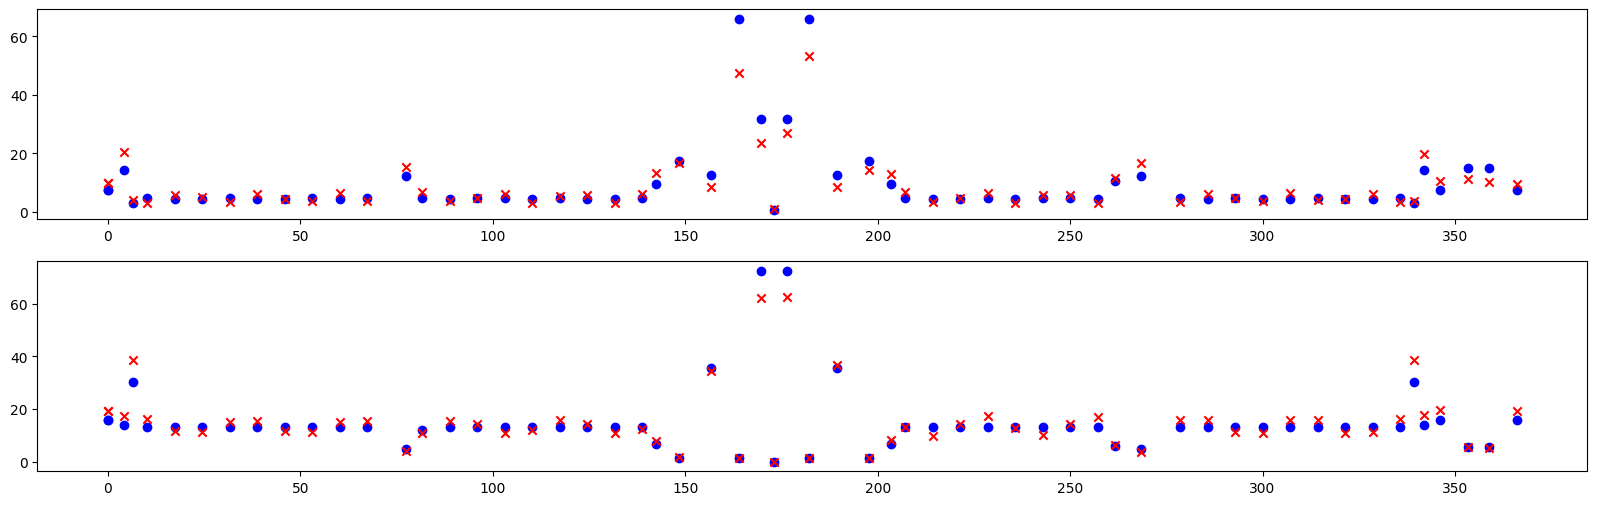

In [9]:
# Compare twiss

bx = torch.zeros(model.size, dtype=dtype, device=device)
by = torch.zeros(model.size, dtype=dtype, device=device)

from harmonica.parameterization import wolski_to_lb
for i in range(model.size):
    _, bx[i], _, _, _, _, _, by[i], *_ = wolski_to_lb(model.out_wolski[i])
    
plt.figure(figsize=(20, 2*3))

ax1 = plt.subplot(211)
ax1.scatter(model.time.cpu().numpy(),  model.bx.cpu().numpy(), marker='o', color='blue')
ax1.scatter(model.time.cpu().numpy(),  bx.cpu().numpy(), marker='x', color='red')

ax2 = plt.subplot(212)
ax2.scatter(model.time.cpu().numpy(),  model.by.cpu().numpy(), marker='o', color='blue')
ax2.scatter(model.time.cpu().numpy(),  by.cpu().numpy(), marker='x', color='red')

plt.show()

In [10]:
# Minimum tune approach

from harmonica.parameterization import id_symplectic
S = id_symplectic(1)
M = model.turn
MUA, MUB = 2.0*numpy.pi*model.out_tune
A, B, C, D = M[0:2, 0:2], M[0:2, 2:4], M[2:4, 0:2], M[2:4, 2:4]
print(torch.allclose(M, torch.vstack([torch.hstack([A, B]), torch.hstack([C, D])])))
print(((C - S @ B.T @ S).det().abs().sqrt()/(numpy.pi*(MUA.sin() + MUB.sin()))).item())

True
-0.008427800604918089


In [11]:
# Save configuration for model with errors

model.config_coupled('test.yaml', normal=model.out_normal, sigma_normal=torch.zeros_like(model.out_normal))

# Load saved configuration and compare normalization matrices

test = Model(path='test.yaml', model='coupled')
torch.allclose(model.out_normal, test.normal)

True